In [1]:
import pandas as pd
import numpy as np

# ***#1 Data cleaning***

In [2]:
df = pd.read_csv('/content/spam.csv',encoding='latin-1').dropna(axis =1,how = 'any')
df.columns = ['labels','message']
df

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df.isnull().sum()

,0
labels,0
message,0


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['labels'] = le.fit_transform(df['labels'])

In [5]:
df.sample(5)

,labels,message
3259,0,I'm always looking for an excuse to be in the ...
2772,0,Still in customer place
1839,0,Are we doing the norm tomorrow? I finish just ...
363,0,Busy here. Trying to finish for new year. I am...
1828,0,May i call You later Pls


In [6]:
#checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [7]:
df  = df.drop_duplicates(keep = 'first')

In [8]:
df.shape

(5169, 2)

# ***#2 EDA***

In [9]:
#checks if the data is balanced or not
df['labels'].value_counts()

,count
labels,
0,4516
1,653


Text(0, 0.5, 'count')

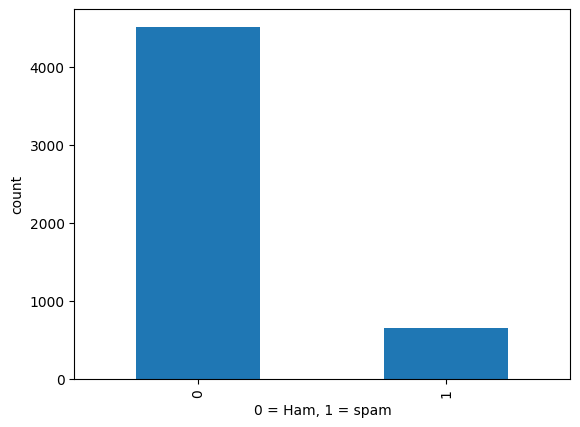

In [10]:
#schematic representation of data in piechart and bargraph format
import matplotlib.pyplot as plt
df['labels'].value_counts().plot(kind = 'bar')
plt.xlabel('0 = Ham, 1 = spam')
plt.ylabel('count')


([<matplotlib.patches.Wedge at 0x79d3b490ce60>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

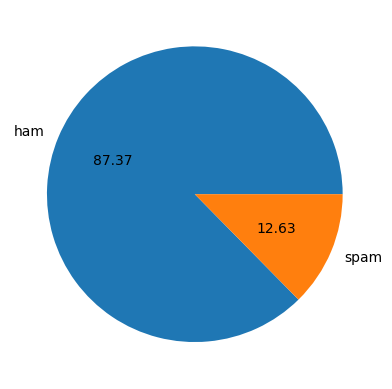

In [11]:
#piechart
plt.pie(df['labels'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f')


In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
df['characters_count'] = df['message'].apply(len)

/tmp/ipython-input-1212001223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['characters_count'] = df['message'].apply(len)


In [14]:
df.sample(5)

,labels,message,characters_count
1869,0,Mom wants to know where you at,30
2200,0,Haha... can... But i'm having dinner with my c...,54
2927,0,Anything...,11
3543,0,Lol ok ill try to send. Be warned Sprint is de...,84
4202,0,C movie is juz last minute decision mah. Juz w...,85


In [15]:
df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))

/tmp/ipython-input-267352958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))


In [16]:
df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

/tmp/ipython-input-1666743428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [17]:
df.head()

,labels,message,characters_count,words_count,sentence count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [18]:
df.sample(5)

,labels,message,characters_count,words_count,sentence count
1274,0,Let me know how to contact you. I've you settl...,81,22,3
42,1,07732584351 - Rodger Burns - MSG = We tried to...,172,34,2
3826,1,Congratulations U can claim 2 VIP row A Ticket...,162,29,1
477,0,Tension ah?what machi?any problem?,34,9,1
5515,0,You are a great role model. You are giving so ...,245,61,4


In [19]:
df[['sentence count','words_count','characters_count']].describe()

,sentence count,words_count,characters_count
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [20]:
#spam message analysis
df[df['labels']==1][['sentence count', 'words_count', 'characters_count']].describe()

,sentence count,words_count,characters_count
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


In [21]:
#ham  message analysis
df[df['labels']==0][['sentence count', 'words_count', 'characters_count']].describe()


,sentence count,words_count,characters_count
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000


<Axes: xlabel='characters_count', ylabel='Count'>

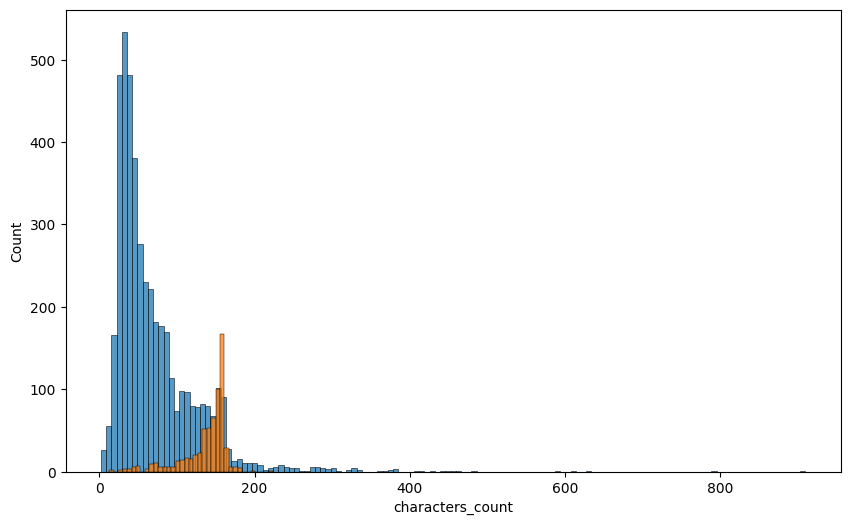

In [22]:
#Comparing the number of characters and numbere of words in spam and ham messages
import seaborn as sns
plt.figure(figsize = (10,6))
sns.histplot(df[df['labels']== 0]['characters_count'])
sns.histplot(df[df['labels']== 1]['characters_count'])

<Axes: xlabel='words_count', ylabel='Count'>

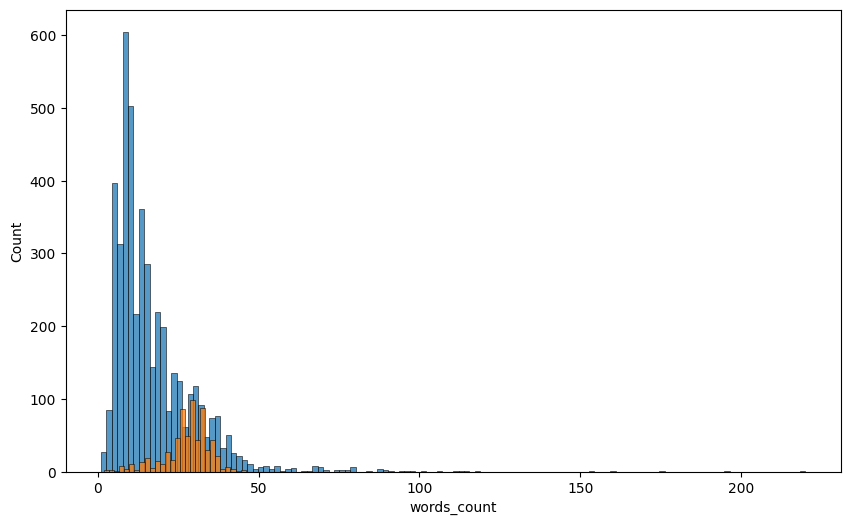

In [23]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['labels']==0]['words_count'])
sns.histplot(df[df['labels']==1]['words_count'])

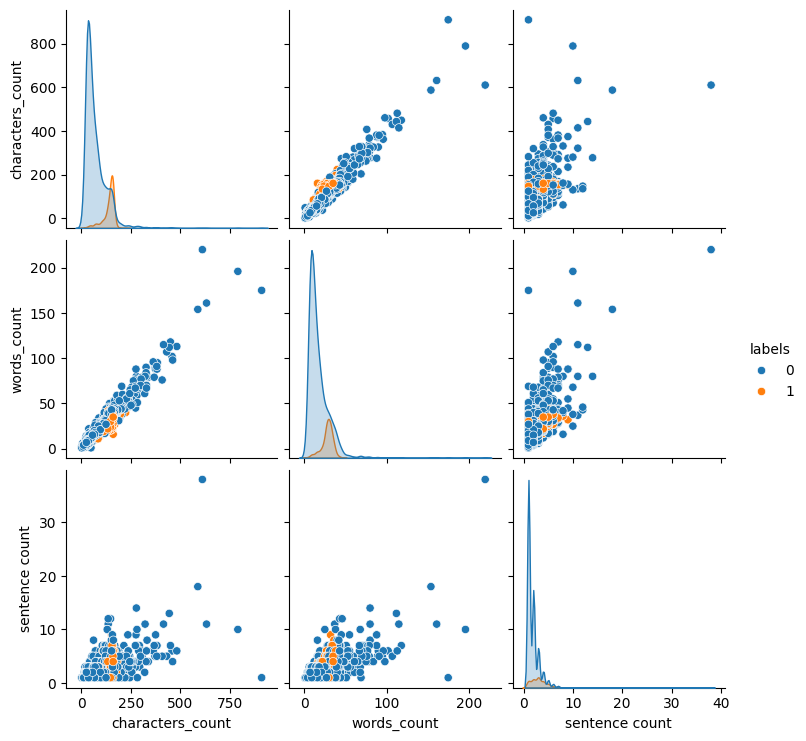

In [24]:
sns.pairplot(df,hue = 'labels')

In [25]:
from wordcloud import WordCloud
wc = WordCloud(width = 500 , height = 500 , min_font_size = 10 , background_color = 'white')

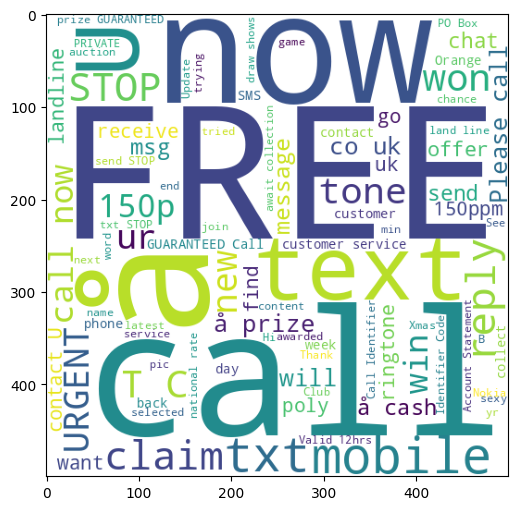

In [26]:
#for spam
spam_wc = wc.generate(df[df['labels'] == 1]['message'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)

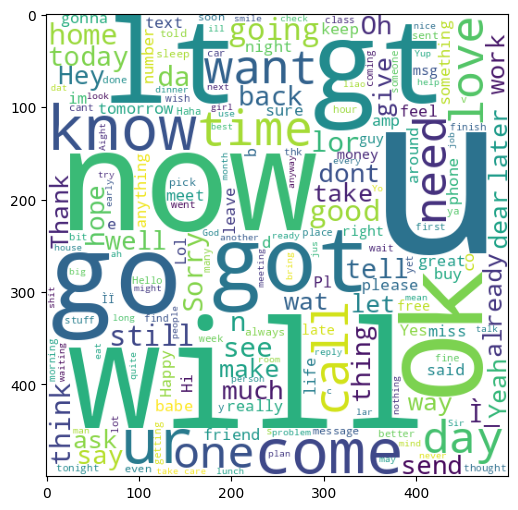

In [27]:
#ham message info
ham_wc = wc.generate(df[df['labels']==0]['message'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)

In [28]:
spam_corpus = []
for msg in df[df['labels']==1]['message'].tolist():

  for word in msg.split():
    spam_corpus.append(word)

In [29]:
len(spam_corpus)

15464

/tmp/ipython-input-3353852527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))
/tmp/ipython-input-3353852527.py:2: UserWarning: 
The palette list has fewer values (8) than needed (30) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))


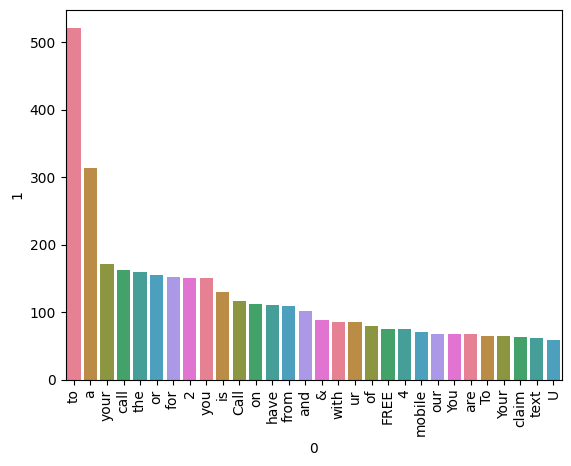

In [30]:
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))
plt.xticks(rotation = 'vertical')
plt.show(       )

In [31]:
ham_corpus = []
for msg in df[df['labels']== 0]['message']:
  for word in msg.split():
    ham_corpus.append(word)


In [32]:
len(ham_corpus)

63832

/tmp/ipython-input-463792093.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))
/tmp/ipython-input-463792093.py:1: UserWarning: 
The palette list has fewer values (6) than needed (30) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))


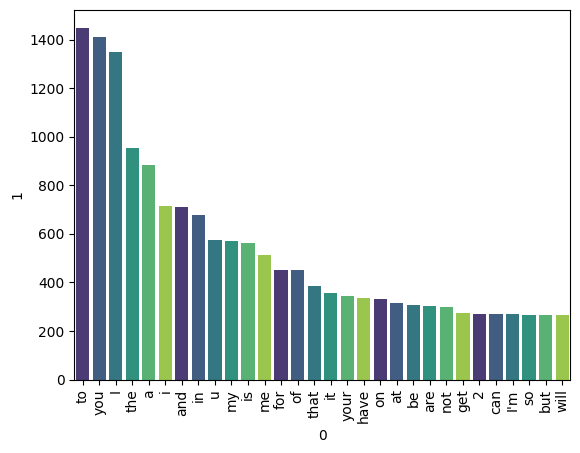

In [33]:
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))
plt.xticks(rotation='vertical')
plt.show()

# ***#3 DATA Preprocessing***

In [34]:
nltk.download('stopwords')
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [35]:
def clean_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)
  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [36]:
clean_text("I had a huge crush on this 10/10 baddie in my college whose name was nimrat ngl!" )

'huge crush baddi colleg whose name nimrat ngl'

In [37]:
df['cleaned_text'] = df['message'].apply(clean_text)

/tmp/ipython-input-669343678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_text'] = df['message'].apply(clean_text)


In [38]:
df.sample(5)

,labels,message,characters_count,words_count,sentence count,cleaned_text
1085,0,FR'NDSHIP is like a needle of a clock. Though ...,158,45,5,like needl clock though v r clock v r nt abl 2...
4988,0,So your telling me I coulda been your real Val...,96,23,3,tell coulda real valentin u never pick noth
2177,0,Oh k :)why you got job then whats up?,37,12,1,oh k got job what
5177,0,Very strange. and are watching the 2nd one n...,86,21,3,strang watch 2nd one bed sweet dream miss u
5099,0,"Ah, well that confuses things, doesnt it? I th...",166,38,3,ah well confus thing doesnt thought friend may...


# ***#4 Model_Training***

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=4000)

In [40]:
X = tfidf.fit_transform(df['cleaned_text']).toarray()

In [41]:
X.shape

(5169, 4000)

In [42]:
y = df['labels'].values

In [43]:
y


array([0, 0, 1, ..., 0, 0, 0])

In [44]:
#Train-test split

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [46]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
import sklearn.metrics as metrics

In [47]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [48]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(metrics.accuracy_score(y_test,y_pred1))
print(metrics.r2_score(y_test,y_pred1))
print(metrics.confusion_matrix(y_test,y_pred1))
print(metrics.precision_score(y_test,y_pred1))

0.8636363636363636
-0.13101896745665398
[[772 117]
 [ 24 121]]
0.5084033613445378


***r2_score produced is in negative***

In [49]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(metrics.accuracy_score(y_test,y_pred2))
print(metrics.r2_score(y_test,y_pred2))
print(metrics.confusion_matrix(y_test,y_pred2))
print(metrics.precision_score(y_test,y_pred2))

0.9709864603481625
0.7593576664985843
[[888   1]
 [ 29 116]]
0.9914529914529915


***r2_score produced is positive***

In [50]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(metrics.accuracy_score(y_test,y_pred3))
print(metrics.r2_score(y_test,y_pred3))
print(metrics.confusion_matrix(y_test,y_pred3))
print(metrics.precision_score(y_test,y_pred3))

0.971953578336557
0.7673790776152981
[[885   4]
 [ 25 120]]
0.967741935483871


***choosing MNB as it's precision score is max***

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [52]:
svc = SVC(kernel = 'sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear',penalty='l1')
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
abc = AdaBoostClassifier(n_estimators = 50,random_state=2)
bc = BaggingClassifier(n_estimators = 50,random_state=2)
etc = ExtraTreesClassifier(n_estimators = 50 , random_state =2)
gbdt = GradientBoostingClassifier(n_estimators = 50 , random_state = 2)
xgb = XGBClassifier(n_estimators = 50 , random_state = 2)

In [53]:
clfs = {
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [54]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  accuracy = metrics.accuracy_score(y_test,y_pred)
  precision = metrics.precision_score(y_test,y_pred)

  return accuracy,precision

In [55]:
#train_classifier(svc,X_train,y_train,X_test,y_test)

In [56]:
accuracy_list = []
precision_list = []

for name,clf in clfs.items():
  current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)
  print(f'{name} accuracy is {current_accuracy}')
  print(f'{name} precision is {current_precision}')
  accuracy_list.append(current_accuracy)
  precision_list.append(current_precision)

SVC accuracy is 0.97678916827853
SVC precision is 0.9548872180451128
KN accuracy is 0.9061895551257253
KN precision is 1.0
NB accuracy is 0.9709864603481625
NB precision is 0.9914529914529915
DT accuracy is 0.9313346228239845
DT precision is 0.8032786885245902
LR accuracy is 0.9477756286266924
LR precision is 0.8699186991869918
RF accuracy is 0.9709864603481625
RF precision is 0.9914529914529915
AdaBoost accuracy is 0.9148936170212766
AdaBoost precision is 0.8
BgC accuracy is 0.960348162475822
BgC precision is 0.8661971830985915
ETC accuracy is 0.9758220502901354
ETC precision is 0.9918032786885246
GBDT accuracy is 0.9439071566731141
GBDT precision is 0.9484536082474226
xgb accuracy is 0.971953578336557
xgb precision is 0.9603174603174603


In [57]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_list,'Precision':precision_list}).sort_values('Precision',ascending =False)

In [58]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.906190,1.000000
8,ETC,0.975822,0.991803
2,NB,0.970986,0.991453
5,RF,0.970986,0.991453
10,xgb,0.971954,0.960317
0,SVC,0.976789,0.954887
9,GBDT,0.943907,0.948454
4,LR,0.947776,0.869919
7,BgC,0.960348,0.866197
3,DT,0.931335,0.803279


In [59]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")


In [60]:

performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.906190
1,ETC,Accuracy,0.975822
2,NB,Accuracy,0.970986
3,RF,Accuracy,0.970986
4,xgb,Accuracy,0.971954
5,SVC,Accuracy,0.976789
6,GBDT,Accuracy,0.943907
7,LR,Accuracy,0.947776
8,BgC,Accuracy,0.960348
9,DT,Accuracy,0.931335


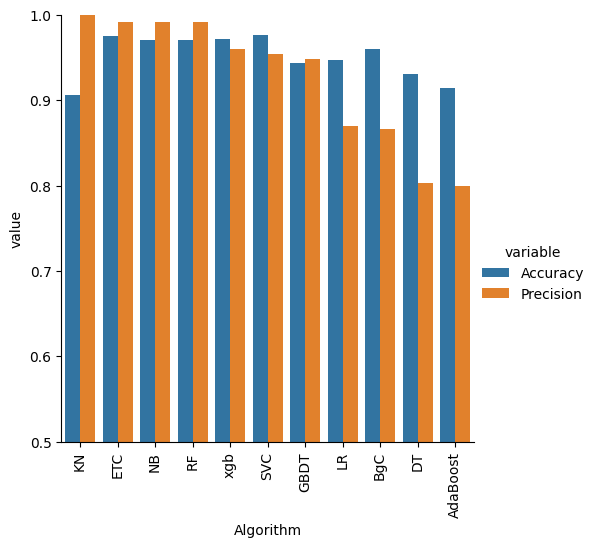

In [61]:
sns.catplot(x = 'Algorithm', y = 'value', hue = 'variable', data = performance_df1, kind = 'bar', height =5)
plt.ylim(0.5,1.0)
plt.xticks(rotation = 'vertical')
plt.show()

In [71]:
#choosing the model based on voting methods
svc = SVC(kernel ='sigmod',gamma = 1.0,)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators =50 ,random_state=2)

In [72]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators = [('svm',svc),('nb',mnb),('et',etc)],voting = 'soft')

In [67]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm', SVC(gamma=1.0, kernel='sigmoid')),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [68]:
VotingClassifier(estimators = [('svm',SVC(gamma=1.0,kernel ='sigmoid',probability=True)),('nb',MultinomialNB()),('et',ExtraTreesClassifier(n_estimators =50 ,random_state=2))],voting = 'soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [73]:
y_pred = voting.predict(X_test)
print('accuracy',metrics.accuracy_score(y_test,y_pred))
print('precision',metrics.precision_score(y_test,y_pred))

accuracy 0.9825918762088974
precision 1.0


In [74]:
#Now applying stack Classifier
from sklearn.ensemble import StackingClassifier
estimators = [('svm',svc),('nb',mnb),('et',etc)]
final_boss = RandomForestClassifier()

In [75]:
clf = StackingClassifier(estimators = estimators,final_estimator=final_boss)

In [76]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print('accuracy',metrics.accuracy_score(y_test,y_pred))
print('precison',metrics.precision_score(y_test,y_pred))

accuracy 0.9816247582205029
precison 0.9565217391304348


In [77]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))

In [78]:
tfidf = pickle.load(open('vectorizer.pkl','rb'))

In [79]:
model = pickle.load(open('model.pkl','rb'))


In [81]:
text = ["Congratulations! You won a jackasspot."]
vecto_input = tfidf.transform(text).toarray() # Convert sparse input to dense
result = model.predict(vecto_input)[0]
print(result)

0
